In [1]:
TASK = "figure_recreation_lohoff-2b"

In [2]:
import os
import shutil
import sys
from functools import partial
from pathlib import Path
from queue import Queue

from langchain_core.messages import HumanMessage
from openai import RateLimitError

sys.path.append(str(Path.cwd().parent / "src"))

### configure logging
from config import DATA_DIR
from notebook_utils import tee_output
log_path = Path.cwd() / f"outputs/{TASK}/transcript.log"
log_path.parent.mkdir(parents=True, exist_ok=True)
log_path.write_text("")
tee = partial(tee_output, path=log_path)

### reset data directory
from notebook_utils import _reset_data_directories
_reset_data_directories()


### Task

In [3]:
### Task Files

data_src_dir = Path.cwd() / "data"
shutil.copy(data_src_dir / "dataset_lohoff_et_al_seqfish.h5ad", DATA_DIR / "dataset/") # dataset
shutil.copy(data_src_dir / "reference_lohoff-2b.png", DATA_DIR / "uploads/")           # reference image
shutil.copy(data_src_dir / "colormap.yaml", DATA_DIR / "uploads/")                     # colormap for consistency between panels
                                                                                       # colormap is generated by TissueAgent given the figure legend and dataset
print("Files present in DATA_DIR:", end="\n - ")
files = [str(f.relative_to(DATA_DIR)) for f in DATA_DIR.rglob("*") if f.is_file()]
print("\n - ".join(files))

Files present in DATA_DIR:
 - .DS_Store
 - dataset/dataset_lohoff_et_al_seqfish.h5ad
 - uploads/colormap.yaml
 - uploads/reference_lohoff-2b.png


In [4]:
### Prompt

prompt = """
I have provided a spatial transcriptomics dataset in dataset_lohoff_et_al_seqfish.h5ad. Help me plot a spatial
scatterplot, where the position of each cell is its location, and the color of a cell is determined by the cell
type, according to colormap.yaml. The y-axis should be inverted. A reference image is included reference_lohoff-2b.png.
The plot should be as close as possible to the reference.
""".replace("\n", " ")

### Initialize TissueAgent

In [5]:
from graph.graph import create_tissueagent_graph

def _bind_retry(model):
    """Wrap a model with retry logic for rate-limit errors."""
    return model.with_retry(
        retry_if_exception_type = (RateLimitError,),
        stop_after_attempt = 6,
    )
state_queue = Queue()

with tee():
    graph = create_tissueagent_graph(state_queue, _bind_retry)
    tissueagent = graph.compile()

/Users/dustinm/Projects/research/ma-lab/TissueAgent/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/dustinm/Projects/research/ma-lab/TissueAgent/.venv/lib/python3.12/site-packages/anndata/__init__.py:44: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/Users/dustinm/Projects/research/ma-lab/TissueAgent/.venv/lib/python3.12/site-packages/anndata/__init__.py:44: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/Users/dustinm/Projects/research/ma-lab/TissueAgent/.venv/lib/python3.12/site-packages/anndata/__init__.py:44: FutureWarning: Im

### Invoke TissueAgent

In [6]:
user_message = HumanMessage(content=prompt)
agent_state = {"messages": [user_message], "replan_count": 0, "replan_history": []}

with tee():
    result = tissueagent.invoke({"messages": [("user", prompt)]})

2026-03-24 21:01:47 | INFO     | Message Info
Type: ai

Name: planner_agent

ID:   run--d67601ff-e9db-4ff8-9b4e-087e5c4044b7-0

Content:
ToolCalls:
  1. {'name': 'template_selector_tool', 'args': {'query_text': 'Create a spatial scatterplot from the uploaded AnnData (.h5ad) spatial transcriptomics dataset, plotting each cell at its spatial location and coloring points by cell type using a provided colormap.yaml. Invert the y-axis and style to match a provided reference image.', 'inputs_available': ['AnnData (.h5ad)', 'spatial coordinates (obs:x,y or obsm:spatial)', 'colormap.yaml', 'reference PNG image']}, 'id': 'call_R3Aaz0BjuXzsr7cJvap1qhDu', 'type': 'tool_call'}

2026-03-24 21:01:47 | INFO     | Message Info
Type: tool

Name: template_selector_tool

ID:   None

Content:
{
  "decision": "ADAPT",
  "template_id": "CELL_ANNOTATION",
  "score": 0.188,
  "scores": {
    "tags": 0.111,
    "keywords": 0.175,
    "io": 0.0,
    "recency": 0.731
  },
  "why": "Partial match (score=0.19); ad

In [7]:
print(result["messages"][-1].content)

Final Answer:
- Report: /Users/dustinm/Projects/research/ma-lab/TissueAgent/data/reports/spatial_scatter_lohoff_seqFISH.md
- Key Results:
  - Rendered a spatial scatterplot for 19,416 cells from dataset_lohoff_et_al_seqfish.h5ad with each cell plotted at its spatial location; y-axis inverted and axes removed to match the reference style.
  - Colored cells by the cell-type column celltype_mapped_refined using the provided colormap.yaml; all 22 observed cell types were found in the colormap (no fallbacks used).
  - Coordinates sourced from obsm['spatial'] with equal aspect and white background; point size=5.0, alpha=0.9, figsize=(6,6), dpi=300.
  - Produced two visuals: a clean base scatter (PNG/SVG) and an overlay aligned to the provided reference image (reference_lohoff-2b.png) using data extents.
- Artifacts:
  - Base scatter (PNG): /Users/dustinm/Projects/research/ma-lab/TissueAgent/data/figures/spatial_scatter.png
  - Base scatter (SVG): /Users/dustinm/Projects/research/ma-lab/Tissu

### Preserve Artifacts

In [8]:
output_dir = Path.cwd() / f"outputs/{TASK}"
output_dir.mkdir(parents=True, exist_ok=True)

for subdir in ("figures", "logs", "tables"):
    src = DATA_DIR / subdir
    dst = output_dir / subdir
    if src.exists():
        shutil.copytree(src, dst, dirs_exist_ok=True)
        print(f"Copied {src} -> {dst}")
    else:
        print(f"Skipped {src} (not found)")

Copied /Users/dustinm/Projects/research/ma-lab/TissueAgent/data/figures -> /Users/dustinm/Projects/research/ma-lab/TissueAgent/demo/outputs/figure_recreation_lohoff-2b/figures
Copied /Users/dustinm/Projects/research/ma-lab/TissueAgent/data/logs -> /Users/dustinm/Projects/research/ma-lab/TissueAgent/demo/outputs/figure_recreation_lohoff-2b/logs
Copied /Users/dustinm/Projects/research/ma-lab/TissueAgent/data/tables -> /Users/dustinm/Projects/research/ma-lab/TissueAgent/demo/outputs/figure_recreation_lohoff-2b/tables


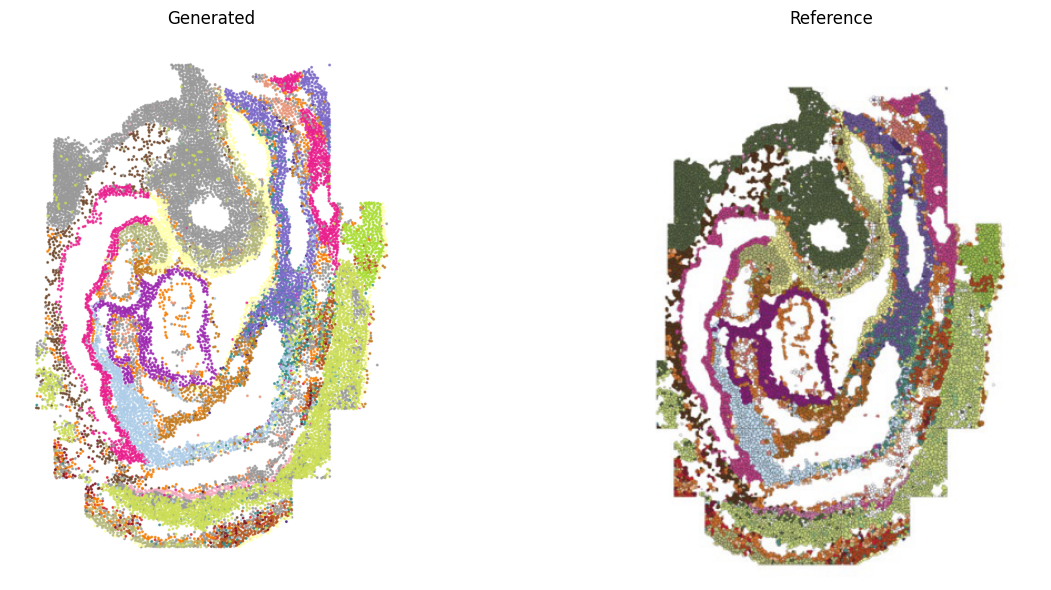

In [11]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display

generated = mpimg.imread(str(Path.cwd() / f"outputs/{TASK}/figures/spatial_scatter.png"))
reference = mpimg.imread(str(data_src_dir / "reference_lohoff-2b.png"))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(generated)
axes[0].set_title("Generated")
axes[0].axis("off")

axes[1].imshow(reference)
axes[1].set_title("Reference")
axes[1].axis("off")

plt.tight_layout()
plt.show()